In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [3]:
df = pd.read_csv("onlinefraud_clean.csv")

In [4]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [5]:
df.shape

(6362620, 11)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


In [7]:
df.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06
mean,2.433972e+02,1.798619e+05,8.338831e+05,8.551137e+05,1.100702e+06,1.224996e+06,1.290820e-03,2.514687e-06
std,1.423320e+02,6.038582e+05,2.888243e+06,2.924049e+06,3.399180e+06,3.674129e+06,3.590480e-02,1.585775e-03
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.560000e+02,1.338957e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.390000e+02,7.487194e+04,1.420800e+04,0.000000e+00,1.327057e+05,2.146614e+05,0.000000e+00,0.000000e+00
75%,3.350000e+02,2.087215e+05,1.073152e+05,1.442584e+05,9.430367e+05,1.111909e+06,0.000000e+00,0.000000e+00
max,7.430000e+02,9.244552e+07,5.958504e+07,4.958504e+07,3.560159e+08,3.561793e+08,1.000000e+00,1.000000e+00


In [8]:
df.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

In [9]:
df.duplicated().sum()

0

In [10]:
df["type"].unique()

array(['PAYMENT', 'TRANSFER', 'CASH_OUT', 'DEBIT', 'CASH_IN'],
      dtype=object)

In [11]:
df["type"].value_counts()

CASH_OUT    2237500
PAYMENT     2151495
CASH_IN     1399284
TRANSFER     532909
DEBIT         41432
Name: type, dtype: int64

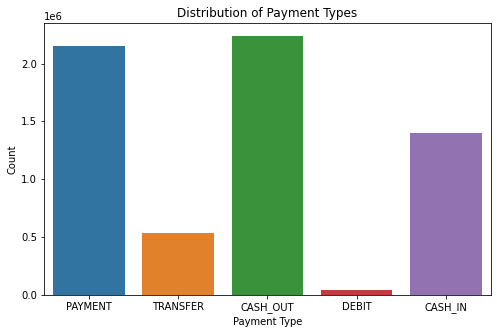

In [12]:
# Visualize Payments Types
plt.figure(figsize=(8,5))

sns.countplot(data=df,x="type")

plt.title("Distribution of Payment Types")
plt.xlabel("Payment Type")
plt.ylabel("Count")

plt.show()

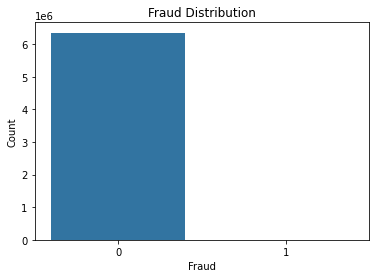

In [13]:
# Fraud Deistribution

plt.figure(figsize=(6,4))

sns.countplot(data=df,x="isFraud")

plt.title("Fraud Distribution")
plt.xlabel("Fraud")
plt.ylabel("Count")

plt.show()

In [14]:
# Fraud Percentage
fraud_percentage = (df["isFraud"].value_counts(normalize=True)*100)

fraud_percentage

0    99.870918
1     0.129082
Name: isFraud, dtype: float64

In [15]:
# Fraud by Payment type
pd.crosstab(df["type"],df["isFraud"])

isFraud,0,1
type,,
CASH_IN,1399284,0
CASH_OUT,2233384,4116
DEBIT,41432,0
PAYMENT,2151495,0
TRANSFER,528812,4097


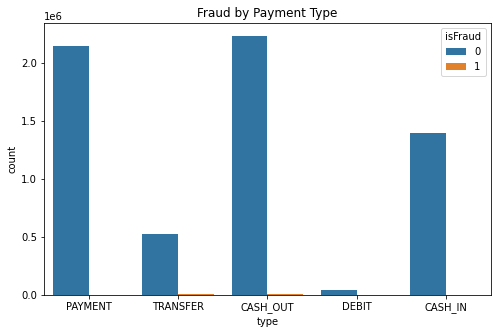

In [16]:
# PLot Fraud by Payment Type
plt.figure(figsize=(8,5))

sns.countplot(data=df,
              x="type",
              hue="isFraud")

plt.title("Fraud by Payment Type")

plt.show()

In [17]:
# Transaction Amount Statistics
df["amount"].describe()

count    6.362620e+06
mean     1.798619e+05
std      6.038582e+05
min      0.000000e+00
25%      1.338957e+04
50%      7.487194e+04
75%      2.087215e+05
max      9.244552e+07
Name: amount, dtype: float64

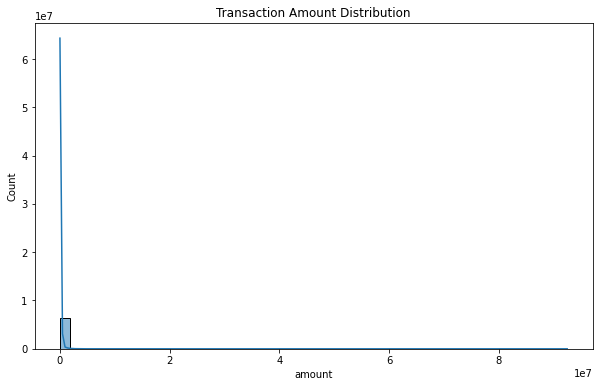

In [19]:
# Distribution of Transaction Amount
plt.figure(figsize=(10,6))

sns.histplot(df["amount"],
             bins=50,
             kde=True)

plt.title("Transaction Amount Distribution")

plt.show()

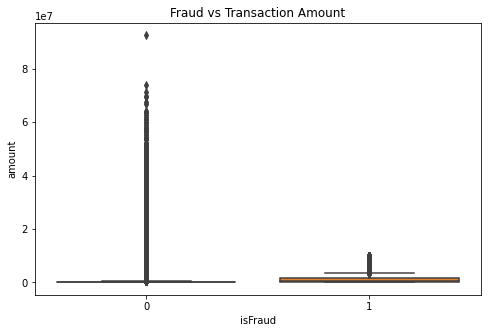

In [20]:
# Boxplot of Transaction Amount
plt.figure(figsize=(8,5))

sns.boxplot(data=df,
            x="isFraud",
            y="amount")

plt.title("Fraud vs Transaction Amount")

plt.show()

In [21]:
# Average Transaction Amount
df.groupby("isFraud")["amount"].mean()

isFraud
0    1.781970e+05
1    1.467967e+06
Name: amount, dtype: float64

In [22]:
# Payment Type Wise Average Amount
df.groupby("type")["amount"].mean().sort_values(ascending=False)

type
TRANSFER    910647.009645
CASH_OUT    176273.964346
CASH_IN     168920.242004
PAYMENT      13057.604660
DEBIT         5483.665314
Name: amount, dtype: float64

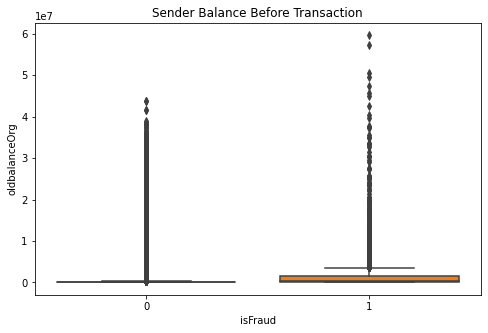

In [23]:
# Sender Balance Anlaysis
plt.figure(figsize=(8,5))

sns.boxplot(data=df, x="isFraud", y="oldbalanceOrg")

plt.title("Sender Balance Before Transaction")

plt.show()

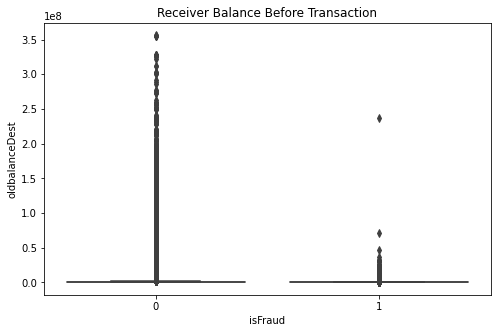

In [24]:
# Receiver Balance Analysis
plt.figure(figsize=(8,5))

sns.boxplot(data=df, x="isFraud", y="oldbalanceDest")

plt.title("Receiver Balance Before Transaction")

plt.show()

In [25]:
# Create New Feature
df["balanceDiff"] = df["oldbalanceOrg"] - df["newbalanceOrig"]

In [26]:
# Check New Feature
df[["oldbalanceOrg", "newbalanceOrig", "balanceDiff"]].head()

,oldbalanceOrg,newbalanceOrig,balanceDiff
0,170136.0,160296.36,9839.64
1,21249.0,19384.72,1864.28
2,181.0,0.00,181.00
3,181.0,0.00,181.00
4,41554.0,29885.86,11668.14


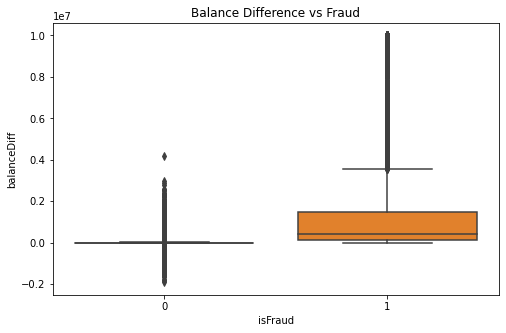

In [27]:
# Boxplot of New Feature
plt.figure(figsize=(8,5))

sns.boxplot(data=df, x="isFraud", y="balanceDiff")

plt.title("Balance Difference vs Fraud")

plt.show()

In [28]:
# Receiver Balance Difference
df["receiverBalanceDiff"] = df["newbalanceDest"] - df["oldbalanceDest"]

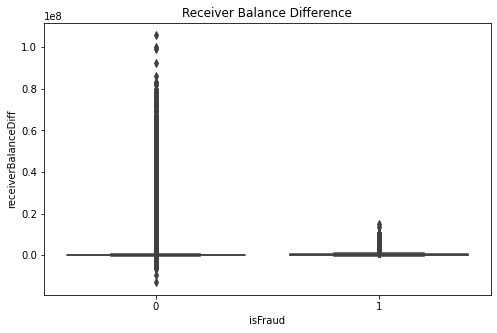

In [29]:
# Visualize Receiver Balance Difference

plt.figure(figsize=(8,5))

sns.boxplot(data=df, x="isFraud", y="receiverBalanceDiff")

plt.title("Receiver Balance Difference")

plt.show()

In [30]:
# Fraud Percentage by Payment Type
fraud_rate = pd.crosstab(df["type"], df["isFraud"], normalize="index")*100

fraud_rate.round(2)

isFraud,0,1
type,,
CASH_IN,100.00,0.00
CASH_OUT,99.82,0.18
DEBIT,100.00,0.00
PAYMENT,100.00,0.00
TRANSFER,99.23,0.77


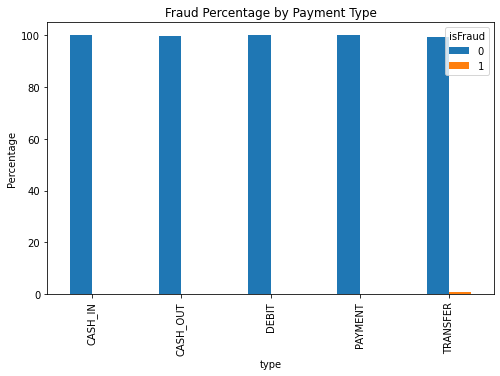

In [31]:
# Plot Fraud Rate
fraud_rate.plot(kind="bar", figsize=(8,5))

plt.title("Fraud Percentage by Payment Type")
plt.ylabel("Percentage")

plt.show()

In [32]:
# Create a new numeric column without copying the dataframe
df["type_code"] = df["type"].astype("category").cat.codes

In [33]:
df[["type", "type_code"]].head()

,type,type_code
0,PAYMENT,3
1,PAYMENT,3
2,TRANSFER,4
3,CASH_OUT,1
4,PAYMENT,3


In [35]:
df["balanceDiff"] = df["oldbalanceOrg"] - df["newbalanceOrig"]

df["receiverBalanceDiff"] = df["newbalanceDest"] - df["oldbalanceDest"]

In [36]:
# Correlation Matrix
corr_columns = [
    "type_code",
    "amount",
    "oldbalanceOrg",
    "newbalanceOrig",
    "oldbalanceDest",
    "newbalanceDest",
    "balanceDiff",
    "receiverBalanceDiff",
    "isFraud"
]

corr_matrix = df[corr_columns].corr()

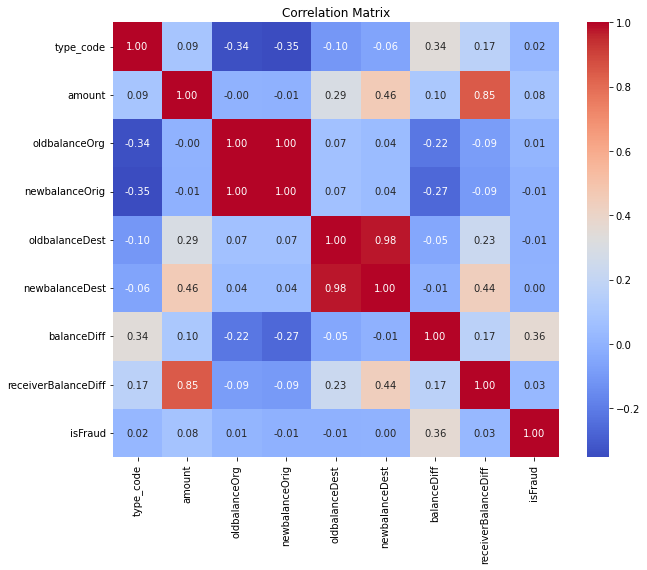

In [37]:
plt.figure(figsize=(10,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()

In [38]:
# Top 10 Highest Trasactions
df.nlargest(10,"amount")

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balanceDiff,receiverBalanceDiff,type_code
3686583,276,TRANSFER,92445516.64,C1715283297,0.0,0.0,C439737079,9.595980e+03,9.245511e+07,0,0,0.0,9.244552e+07,4
4060598,300,TRANSFER,73823490.36,C2127282686,0.0,0.0,C753026640,9.362401e+07,1.674475e+08,0,0,0.0,7.382349e+07,4
4146397,303,TRANSFER,71172480.42,C2044643633,0.0,0.0,C84111522,1.134615e+08,1.846340e+08,0,0,0.0,7.117248e+07,4
3946920,286,TRANSFER,69886731.30,C1425667947,0.0,0.0,C167875008,1.515387e+08,2.214254e+08,0,0,0.0,6.988673e+07,4
3911956,284,TRANSFER,69337316.27,C1584456031,0.0,0.0,C1472140329,1.130072e+08,1.823446e+08,0,0,0.0,6.933732e+07,4
3937152,286,TRANSFER,67500761.29,C811810230,0.0,0.0,C1757599079,8.635615e+07,1.538569e+08,0,0,0.0,6.750076e+07,4
4105338,302,TRANSFER,66761272.21,C420748282,0.0,0.0,C1073241084,6.874206e+07,1.355033e+08,0,0,0.0,6.676127e+07,4
3892529,284,TRANSFER,64234448.19,C1139847449,0.0,0.0,C65111466,6.597691e+07,1.663021e+08,0,0,0.0,1.003252e+08,4
3991638,298,TRANSFER,63847992.58,C300140823,0.0,0.0,C514940761,7.217149e+07,1.360195e+08,0,0,0.0,6.384799e+07,4
4143801,303,TRANSFER,63294839.63,C372535854,0.0,0.0,C1871605747,7.512528e+07,1.384201e+08,0,0,0.0,6.329484e+07,4


In [39]:
# Fraud Transaction Only
fraud = df[df["isFraud"]==1]
 
fraud.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balanceDiff,receiverBalanceDiff,type_code
2,1,TRANSFER,181.0,C1305486145,181.0,0.0,C553264065,0.0,0.0,1,0,181.0,0.0,4
3,1,CASH_OUT,181.0,C840083671,181.0,0.0,C38997010,21182.0,0.0,1,0,181.0,-21182.0,1
251,1,TRANSFER,2806.0,C1420196421,2806.0,0.0,C972765878,0.0,0.0,1,0,2806.0,0.0,4
252,1,CASH_OUT,2806.0,C2101527076,2806.0,0.0,C1007251739,26202.0,0.0,1,0,2806.0,-26202.0,1
680,1,TRANSFER,20128.0,C137533655,20128.0,0.0,C1848415041,0.0,0.0,1,0,20128.0,0.0,4


In [40]:
# Genuine Transactions 
genuine = df[df["isFraud"]==0]

genuine.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balanceDiff,receiverBalanceDiff,type_code
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0,9839.64,0.0,3
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0,1864.28,0.0,3
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0,11668.14,0.0,3
5,1,PAYMENT,7817.71,C90045638,53860.0,46042.29,M573487274,0.0,0.0,0,0,7817.71,0.0,3
6,1,PAYMENT,7107.77,C154988899,183195.0,176087.23,M408069119,0.0,0.0,0,0,7107.77,0.0,3


In [42]:
# Compare Fraud and Genuine
genuine.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balanceDiff,receiverBalanceDiff,type_code
count,6.354407e+06,6.354407e+06,6.354407e+06,6.354407e+06,6.354407e+06,6.354407e+06,6354407.0,6354407.0,6.354407e+06,6.354407e+06,6.354407e+06
mean,2.432357e+02,1.781970e+05,8.328287e+05,8.559702e+05,1.101421e+06,1.224926e+06,0.0,0.0,-2.314152e+04,1.235048e+05,1.713139e+00
std,1.421402e+02,5.962370e+05,2.887144e+06,2.924987e+06,3.399202e+06,3.673816e+06,0.0,0.0,1.062233e+05,8.104223e+05,1.349619e+00
min,1.000000e+00,1.000000e-02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0,0.0,-1.915268e+06,-1.306083e+07,0.000000e+00
25%,1.560000e+02,1.336840e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0,0.0,0.000000e+00,0.000000e+00,1.000000e+00
50%,2.390000e+02,7.468472e+04,1.406900e+04,0.000000e+00,1.333118e+05,2.148817e+05,0.0,0.0,0.000000e+00,0.000000e+00,1.000000e+00
75%,3.340000e+02,2.083648e+05,1.069695e+05,1.447307e+05,9.441446e+05,1.111975e+06,0.0,0.0,1.010213e+04,1.489826e+05,3.000000e+00
max,7.180000e+02,9.244552e+07,4.381886e+07,4.368662e+07,3.560159e+08,3.561793e+08,0.0,0.0,4.164236e+06,1.056878e+08,4.000000e+00


In [47]:
# Save Dataset with New Features
df.to_csv("onlinefraud_final.csv",index=False)